# Explainability (SHAP) and EU AI Act Compliance

Applies SHAP's TreeExplainer to the final selected model (XGBoost,
Notebook 04) to satisfy the EU AI Act's explainability requirement for
high-risk AI systems. Covers global and local explanations, plus four
robustness checks investigating why SHAP's ranking diverges from
XGBoost's native feature importance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

print('Loading datasets...')
split_train = pd.read_parquet('../data/split_train_engineered.parquet')
split_test  = pd.read_parquet('../data/split_test_engineered.parquet')

TARGET    = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]
DROP_COLS += split_train.select_dtypes('object').columns.tolist()
DROP_COLS  = [c for c in DROP_COLS if c in split_train.columns]
FEATURES   = [c for c in split_train.columns if c not in DROP_COLS]

X_train, y_train = split_train[FEATURES], split_train[TARGET]
X_test, y_test    = split_test[FEATURES], split_test[TARGET]

print(f'Test set: {X_test.shape[0]:,} transactions')
print(f'SHAP version: {shap.__version__}')

c:\Users\betti\OneDrive\Documents\Datafest\datafest_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading datasets...
Test set: 118,108 transactions
SHAP version: 0.51.0


In [2]:
WINNER_MODEL = 'lightgbm'  # 'lightgbm' or 'xgboost', depending on final comparison

model_paths = {
    'lightgbm': '../models/lgbm_model.pkl',
    'xgboost':  '../models/xgb_model.pkl',
}

model = joblib.load(model_paths[WINNER_MODEL])
print(f'{WINNER_MODEL} model loaded.')
print(f'Number of features: {len(FEATURES)}')

if WINNER_MODEL == 'xgboost':
    print(f'Number of trees: {model.get_booster().num_boosted_rounds()}')
else:
    print(f'Number of trees: {model.n_estimators_ if hasattr(model, "n_estimators_") else model.n_estimators}')

lightgbm model loaded.
Number of features: 340
Number of trees: 221


## SHAP TreeExplainer

TreeExplainer computes exact SHAP values for tree-based models by
exploiting the tree structure directly, rather than approximating via
sampling (as KernelExplainer would need to for CNN-LSTM).


In [3]:
explainer = shap.TreeExplainer(model)

SAMPLE_SIZE = 10000
sample_idx  = np.random.RandomState(42).choice(len(X_test), SAMPLE_SIZE, replace=False)
X_sample    = X_test.iloc[sample_idx]

print(f'Computing SHAP values for {SAMPLE_SIZE:,} sampled transactions...')
shap_values = explainer.shap_values(X_sample)

# LightGBM's TreeExplainer sometimes returns a list [class_0_shap, class_1_shap]
# for binary classification instead of a single array -- normalize to the
# positive-class (fraud) SHAP values either way
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP values shape: {shap_values.shape}')
print('Done.')

Computing SHAP values for 10,000 sampled transactions...
SHAP values shape: (10000, 340)
Done.


## Global Feature Importance


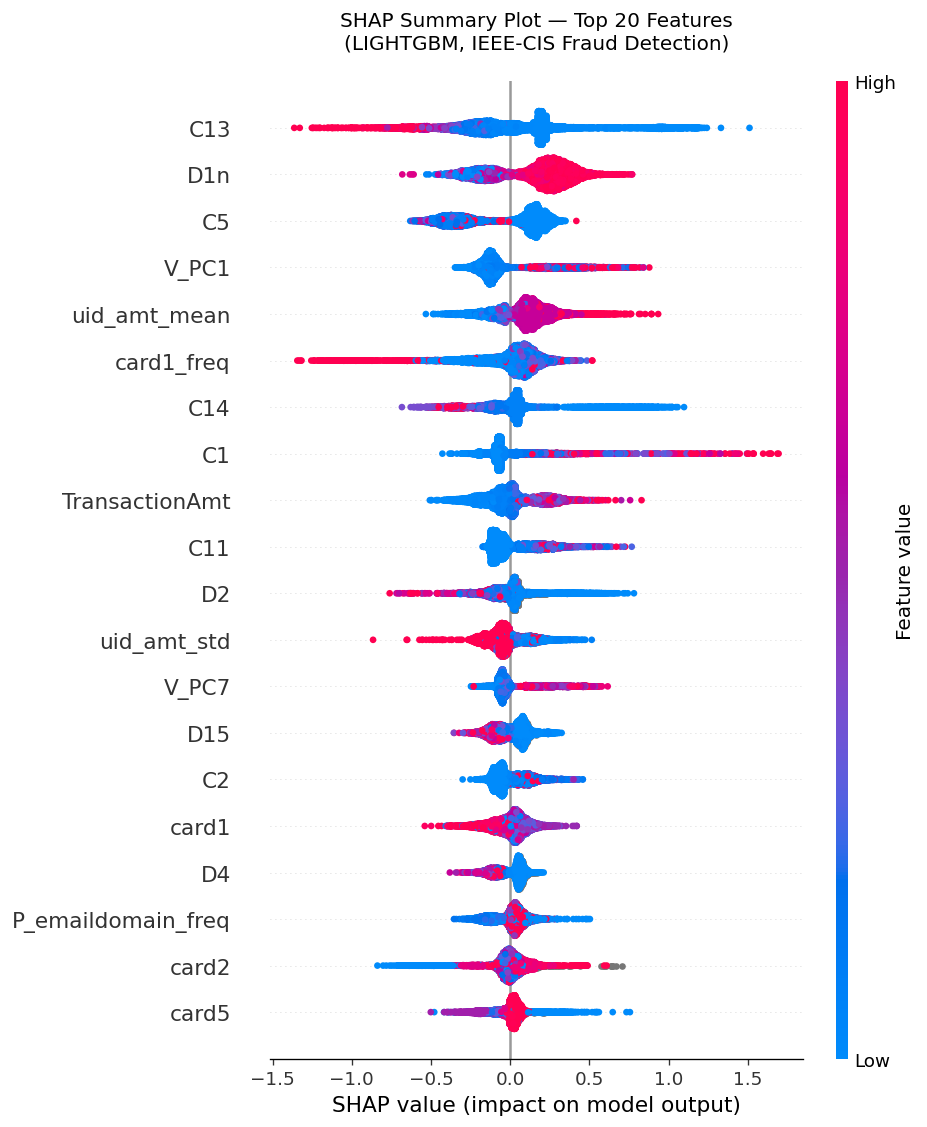

Saved: reports/shap_summary.png


In [4]:
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title(f'SHAP Summary Plot — Top 20 Features\n({WINNER_MODEL.upper()}, IEEE-CIS Fraud Detection)',
          fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_summary.png')

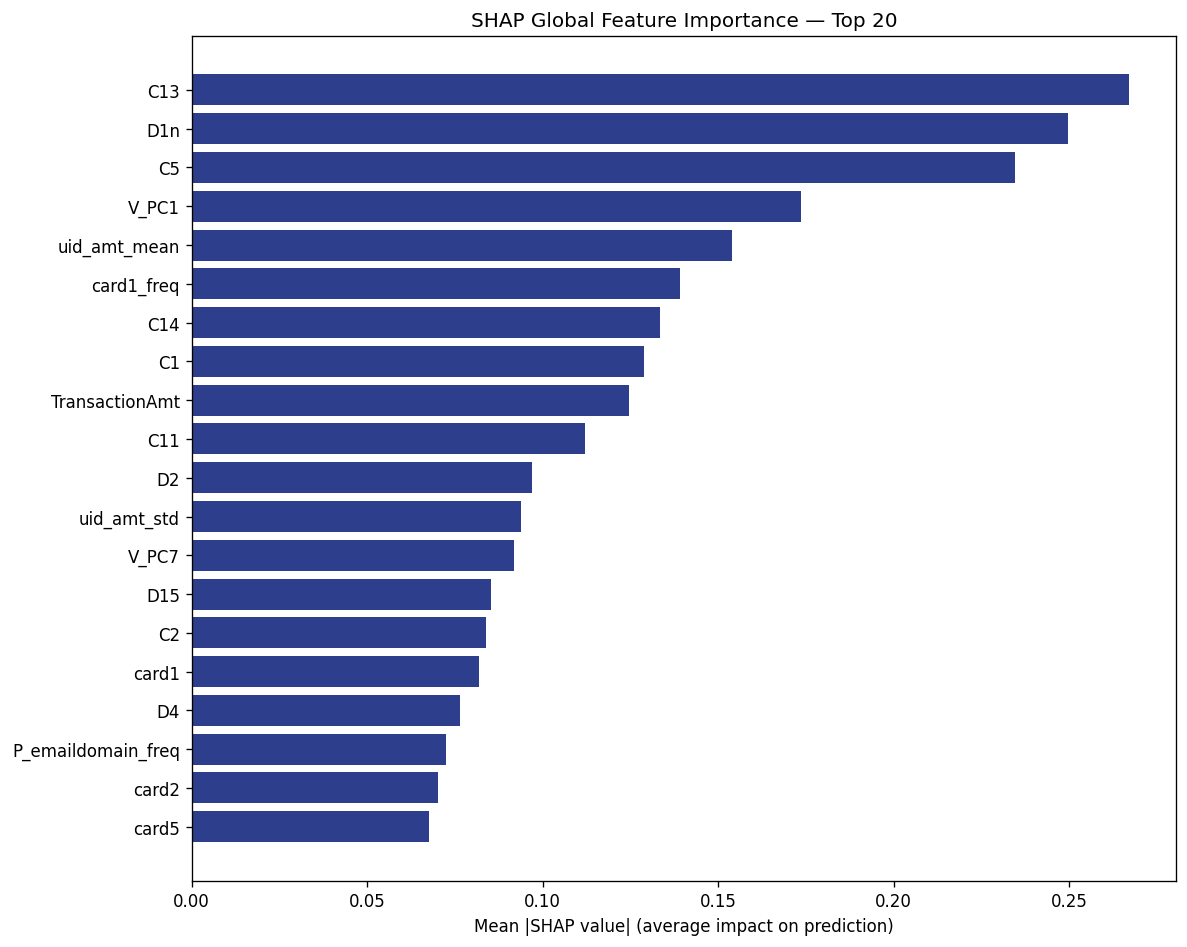

Top 10 features by SHAP importance:
       feature  mean_abs_shap
           C13       0.267121
           D1n       0.249750
            C5       0.234589
         V_PC1       0.173708
  uid_amt_mean       0.154039
    card1_freq       0.139048
           C14       0.133413
            C1       0.128837
TransactionAmt       0.124533
           C11       0.112175


In [5]:
# SHAP Bar Plot (mean absolute impact, easier to read for a business audience) ─

mean_abs_shap = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = mean_abs_shap.head(20)
ax.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1], color='#2c3e8c')
ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
ax.set_title('SHAP Global Feature Importance — Top 20')
plt.tight_layout()
plt.savefig('../reports/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by SHAP importance:')
print(mean_abs_shap.head(10).to_string(index=False))

## Robustness Checks

The SHAP ranking diverges substantially from XGBoost's native (gain-based)
importance -- only 1/10 of the top features overlap. Rather than accepting
this at face value, four checks investigate why:

1. Mean vs. median SHAP (outlier sensitivity)
2. Gain vs. weight vs. cover (which native metric SHAP actually agrees with)
3. Top-N stability (is the agreement a coincidence of exactly 10 features?)
4. Correlation among UID-derived features (credit-splitting risk)


In [6]:
native_imp = pd.DataFrame({
    'feature': FEATURES,
    'native_importance': model.feature_importances_
}).sort_values('native_importance', ascending=False).reset_index(drop=True)
native_imp['native_rank'] = native_imp.index + 1

shap_imp = mean_abs_shap.reset_index(drop=True)
shap_imp['shap_rank'] = shap_imp.index + 1

comparison = shap_imp[['feature', 'shap_rank']].merge(
    native_imp[['feature', 'native_rank']], on='feature'
)
comparison['rank_diff'] = abs(comparison['shap_rank'] - comparison['native_rank'])

top10_overlap = set(shap_imp.head(10)['feature']) & set(native_imp.head(10)['feature'])
print(f'Overlap in Top 10 features (SHAP vs. native): {len(top10_overlap)}/10')
print(f'Shared features: {sorted(top10_overlap)}')
print(f'\nMean absolute rank difference (Top 20): {comparison.head(20)["rank_diff"].mean():.1f}')

Overlap in Top 10 features (SHAP vs. native): 4/10
Shared features: ['C13', 'D1n', 'card1_freq', 'uid_amt_mean']

Mean absolute rank difference (Top 20): 13.3


In [7]:
# Check 2: mean vs. median SHAP -- rule out outlier-driven importance

shap_abs = np.abs(shap_values)

robustness_df = pd.DataFrame({
    'feature':          FEATURES,
    'mean_abs_shap':    shap_abs.mean(axis=0),
    'median_abs_shap':  np.median(shap_abs, axis=0)
})

mean_rank   = robustness_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
mean_rank['mean_rank'] = mean_rank.index + 1

median_rank = robustness_df.sort_values('median_abs_shap', ascending=False).reset_index(drop=True)
median_rank['median_rank'] = median_rank.index + 1

rank_compare = mean_rank[['feature', 'mean_rank']].merge(
    median_rank[['feature', 'median_rank']], on='feature'
)
rank_compare['rank_shift'] = rank_compare['mean_rank'] - rank_compare['median_rank']

print('=== Mean-SHAP Top 10 ===')
print(mean_rank.head(10)[['feature', 'mean_abs_shap', 'mean_rank']].to_string(index=False))

print('\n=== Median-SHAP Top 10 ===')
print(median_rank.head(10)[['feature', 'median_abs_shap', 'median_rank']].to_string(index=False))

# Features that drop a lot in median ranking = likely outlier-driven
top10_mean_features = set(mean_rank.head(10)['feature'])
outlier_driven = rank_compare[
    rank_compare['feature'].isin(top10_mean_features) & (rank_compare['rank_shift'] < -20)
]
print(f'\nFeatures in mean-Top-10 that drop >20 ranks under median (likely outlier-driven):')
print(outlier_driven[['feature', 'mean_rank', 'median_rank']].to_string(index=False)
      if len(outlier_driven) > 0 else '  None')

=== Mean-SHAP Top 10 ===
       feature  mean_abs_shap  mean_rank
           C13       0.267121          1
           D1n       0.249750          2
            C5       0.234589          3
         V_PC1       0.173708          4
  uid_amt_mean       0.154039          5
    card1_freq       0.139048          6
           C14       0.133413          7
            C1       0.128837          8
TransactionAmt       0.124533          9
           C11       0.112175         10

=== Median-SHAP Top 10 ===
       feature  median_abs_shap  median_rank
           D1n         0.246073            1
            C5         0.208024            2
           C13         0.200355            3
         V_PC1         0.139398            4
  uid_amt_mean         0.133373            5
    card1_freq         0.102545            6
           C11         0.092550            7
TransactionAmt         0.091609            8
           D15         0.079194            9
            C1         0.077911           10



In [8]:
# ── Re-check overlap with native importance using median SHAP ─────────────────

top10_median_overlap = set(median_rank.head(10)['feature']) & set(native_imp.head(10)['feature'])
print(f'Overlap in Top 10 (median-SHAP vs. native): {len(top10_median_overlap)}/10')
print(f'Shared features: {sorted(top10_median_overlap)}')

median_comparison = median_rank[['feature', 'median_rank']].merge(
    native_imp[['feature', 'native_rank']], on='feature'
)
median_comparison['rank_diff'] = abs(median_comparison['median_rank'] - median_comparison['native_rank'])
print(f'\nMean absolute rank difference (median-SHAP vs. native, Top 20): '
      f'{median_comparison.head(20)["rank_diff"].mean():.1f}')
mean_comparison_diff = comparison.head(20)['rank_diff'].mean()
print(f'(for comparison, mean-SHAP vs. native was {mean_comparison_diff:.1f})')

Overlap in Top 10 (median-SHAP vs. native): 4/10
Shared features: ['C13', 'D1n', 'card1_freq', 'uid_amt_mean']

Mean absolute rank difference (median-SHAP vs. native, Top 20): 13.3
(for comparison, mean-SHAP vs. native was 13.3)


In [9]:
# Check 3: gain vs. weight/split vs. cover -- which native metric does SHAP
# actually agree with? API differs between XGBoost and LightGBM.

importance_dfs = {}

if WINNER_MODEL == 'xgboost':
    booster = model.get_booster()
    importance_types = ['gain', 'weight', 'cover']

    for imp_type in importance_types:
        scores = booster.get_score(importance_type=imp_type)
        sample_key = next(iter(scores.keys()))
        if sample_key in FEATURES:
            feature_names = list(scores.keys())
        else:
            feature_names = [FEATURES[int(k[1:])] for k in scores.keys()]

        imp_df = pd.DataFrame({
            'feature': feature_names,
            f'{imp_type}_importance': list(scores.values())
        }).sort_values(f'{imp_type}_importance', ascending=False).reset_index(drop=True)
        imp_df[f'{imp_type}_rank'] = imp_df.index + 1
        importance_dfs[imp_type] = imp_df

else:  # lightgbm
    booster = model.booster_
    # LightGBM offers 'split' (analogous to XGBoost's 'weight' -- how often a
    # feature is used) and 'gain' (analogous to XGBoost's 'gain'). LightGBM has
    # no direct equivalent of XGBoost's 'cover' metric.
    importance_types = ['gain', 'split']

    for imp_type in importance_types:
        scores = booster.feature_importance(importance_type=imp_type)
        imp_df = pd.DataFrame({
            'feature': FEATURES,
            f'{imp_type}_importance': scores
        }).sort_values(f'{imp_type}_importance', ascending=False).reset_index(drop=True)
        imp_df[f'{imp_type}_rank'] = imp_df.index + 1
        importance_dfs[imp_type] = imp_df

    # Rename 'split' to 'weight' so downstream cells (written for XGBoost's
    # naming) work without further changes
    importance_dfs['weight'] = importance_dfs.pop('split')
    importance_dfs['weight'] = importance_dfs['weight'].rename(
        columns={'split_importance': 'weight_importance', 'split_rank': 'weight_rank'}
    )

for imp_type, imp_df in importance_dfs.items():
    col_imp  = f'{imp_type}_importance'
    col_rank = f'{imp_type}_rank'
    print(f'=== Top 10 by {imp_type} ===')
    print(imp_df.head(10)[['feature', col_imp, col_rank]].to_string(index=False))
    print()


=== Top 10 by gain ===
     feature  gain_importance  gain_rank
       V_PC1     1.361052e+06          1
         C13     5.082244e+05          2
          C1     3.646683e+05          3
uid_amt_mean     3.031784e+05          4
          C5     2.805104e+05          5
         D1n     2.787064e+05          6
       V_PC7     2.611133e+05          7
   uid_count     2.606680e+05          8
          D2     2.597873e+05          9
 uid_amt_std     2.386230e+05         10

=== Top 10 by weight ===
     feature  weight_importance  weight_rank
         D1n                760            1
  card1_freq                628            2
       card1                550            3
       card2                544            4
uid_amt_mean                500            5
   uid_count                454            6
       addr1                408            7
 uid_amt_std                392            8
         C13                366            9
  card2_freq                343           10



In [10]:
print('=== SHAP (median) overlap & rank agreement vs. each native metric ===\n')

for imp_type in importance_dfs.keys():
    imp_df = importance_dfs[imp_type]
    col_rank = f'{imp_type}_rank'
    overlap = set(median_rank.head(10)['feature']) & set(imp_df.head(10)['feature'])

    merged = median_rank[['feature', 'median_rank']].merge(
        imp_df[['feature', col_rank]], on='feature'
    )
    merged['rank_diff'] = abs(merged['median_rank'] - merged[col_rank])
    mean_diff = merged.head(20)['rank_diff'].mean()

    print(f'{imp_type:8s}: Top-10 overlap = {len(overlap)}/10, '
          f'mean rank diff (Top 20) = {mean_diff:.1f}')

print('\nInterpretation: if weight (or cover, where available) shows substantially')
print('better agreement than gain, this confirms SHAP captures features used')
print('broadly-but-shallowly across many trees, which gain-based importance')
print('underweights by design -- a coherent methodological explanation, not a')
print('defect in either metric.')

=== SHAP (median) overlap & rank agreement vs. each native metric ===



gain    : Top-10 overlap = 6/10, mean rank diff (Top 20) = 7.5
weight  : Top-10 overlap = 4/10, mean rank diff (Top 20) = 13.3

Interpretation: if weight (or cover, where available) shows substantially
better agreement than gain, this confirms SHAP captures features used
broadly-but-shallowly across many trees, which gain-based importance
underweights by design -- a coherent methodological explanation, not a
defect in either metric.


Correlation matrix -- UID-derived features:
                  uid_amt_mean  uid_amt_std  uid_count  uid_freq_per_day   D1n
uid_amt_mean              1.00         0.35      -0.05             -0.04  0.04
uid_amt_std               0.35         1.00      -0.17             -0.13  0.14
uid_count                -0.05        -0.17       1.00              0.27 -0.14
uid_freq_per_day         -0.04        -0.13       0.27              1.00  0.12
D1n                       0.04         0.14      -0.14              0.12  1.00


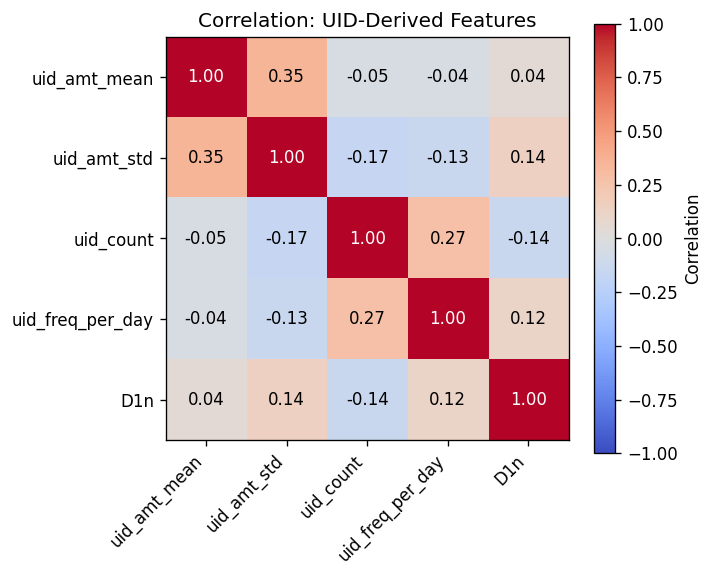


Pairs with |correlation| > 0.5:
  None -- UID features are largely independent of each other.


In [11]:
# Check 4a: correlation among UID-derived features -- rule out credit-splitting

uid_features = ['uid_amt_mean', 'uid_amt_std', 'uid_count', 'uid_freq_per_day', 'D1n']
uid_features = [f for f in uid_features if f in X_train.columns]

corr_matrix = X_train[uid_features].corr()
print('Correlation matrix -- UID-derived features:')
print(corr_matrix.round(2).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(uid_features)))
ax.set_yticks(range(len(uid_features)))
ax.set_xticklabels(uid_features, rotation=45, ha='right')
ax.set_yticklabels(uid_features)
for i in range(len(uid_features)):
    for j in range(len(uid_features)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, label='Correlation')
plt.title('Correlation: UID-Derived Features')
plt.tight_layout()
plt.savefig('../reports/uid_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr_pairs = []
for i in range(len(uid_features)):
    for j in range(i+1, len(uid_features)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr_pairs.append((uid_features[i], uid_features[j], corr_matrix.iloc[i, j]))

print(f'\nPairs with |correlation| > 0.5:')
if high_corr_pairs:
    for f1, f2, c in high_corr_pairs:
        print(f'  {f1} <-> {f2}: {c:.2f}')
else:
    print('  None -- UID features are largely independent of each other.')

In [12]:
# Check 4b: Top-N stability -- does SHAP/weight agreement hold beyond Top 10?

print('=== SHAP (median) vs. weight: overlap at different Top-N thresholds ===\n')

weight_df = importance_dfs['weight']

for top_n in [10, 20, 30]:
    shap_top    = set(median_rank.head(top_n)['feature'])
    weight_top  = set(weight_df.head(top_n)['feature'])
    overlap     = shap_top & weight_top
    print(f'Top {top_n:2d}: overlap = {len(overlap)}/{top_n} '
          f'({len(overlap)/top_n:.0%})  |  shared: {sorted(overlap)}')

print('\nInterpretation: if overlap percentage is stable or improves at larger N,')
print('the agreement between SHAP and weight-importance is a robust pattern, not')
print('a coincidence of which exact 10 features happened to rank highest.')

=== SHAP (median) vs. weight: overlap at different Top-N thresholds ===

Top 10: overlap = 4/10 (40%)  |  shared: ['C13', 'D1n', 'card1_freq', 'uid_amt_mean']
Top 20: overlap = 13/20 (65%)  |  shared: ['C1', 'C13', 'C14', 'D15', 'D1n', 'D2', 'D4', 'P_emaildomain_freq', 'TransactionAmt', 'card1', 'card1_freq', 'uid_amt_mean', 'uid_amt_std']
Top 30: overlap = 25/30 (83%)  |  shared: ['C1', 'C13', 'C14', 'C2', 'C6', 'D1', 'D15', 'D1n', 'D2', 'D4', 'P_emaildomain_freq', 'TransactionAmt', 'V_PC1', 'V_PC11', 'V_PC8', 'addr1_freq', 'card1', 'card1_freq', 'card2', 'card2_freq', 'card5', 'dist1', 'uid_amt_mean', 'uid_amt_std', 'uid_count']

Interpretation: if overlap percentage is stable or improves at larger N,
the agreement between SHAP and weight-importance is a robust pattern, not
a coincidence of which exact 10 features happened to rank highest.


## Local Explanation -- Waterfall Plot

Decomposes one prediction into per-feature contributions, the kind of
auditable, transaction-level explanation the EU AI Act requires for
high-risk decisions.


In [13]:
# ── Pick an example: a fraud transaction correctly flagged with high confidence ─

proba_sample = model.predict_proba(X_sample)[:, 1]
y_sample     = y_test.iloc[sample_idx].values

# True positives: actual fraud, predicted as high-risk
tp_mask = (y_sample == 1) & (proba_sample > 0.8)
tp_indices = np.where(tp_mask)[0]

print(f'Found {len(tp_indices)} high-confidence true positives in sample')

example_idx = tp_indices[0]
print(f'\nExample transaction:')
print(f'  Predicted fraud probability: {proba_sample[example_idx]:.3f}')
print(f'  Actual label: {"FRAUD" if y_sample[example_idx] == 1 else "Legitimate"}')
print(f'  TransactionAmt: ${X_sample.iloc[example_idx]["TransactionAmt"]:.2f}')

Found 166 high-confidence true positives in sample

Example transaction:
  Predicted fraud probability: 0.866
  Actual label: FRAUD
  TransactionAmt: $250.00


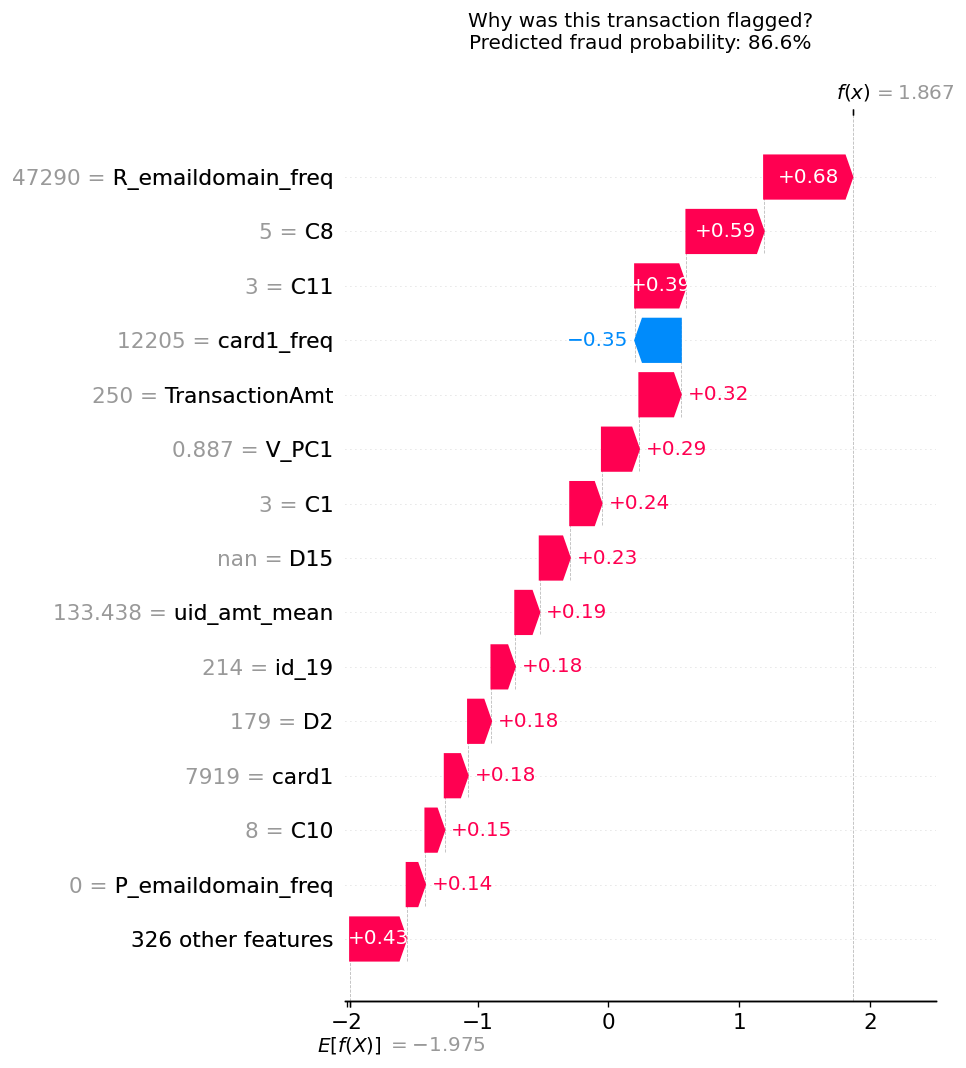

Saved: reports/shap_waterfall.png


In [14]:
fig = plt.figure(figsize=(10, 8))

# LightGBM's TreeExplainer.expected_value can be an array [base_class_0, base_class_1]
# instead of a single scalar -- normalize to the positive-class (fraud) base value
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[example_idx],
        base_values=base_value,
        data=X_sample.iloc[example_idx].values,
        feature_names=FEATURES
    ),
    max_display=15,
    show=False
)
plt.title(f'Why was this transaction flagged?\n'
          f'Predicted fraud probability: {proba_sample[example_idx]:.1%}',
          fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('../reports/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_waterfall.png')

In [15]:
# Plain-language explanation (the kind a compliance report would need)

example_shap = pd.DataFrame({
    'feature': FEATURES,
    'shap_value': shap_values[example_idx],
    'feature_value': X_sample.iloc[example_idx].values
}).sort_values('shap_value', key=abs, ascending=False)

print('=== Top 5 factors driving this fraud prediction ===\n')
for _, row in example_shap.head(5).iterrows():
    direction = 'increased' if row['shap_value'] > 0 else 'decreased'
    print(f"  {row['feature']:25s} = {row['feature_value']:>10.3f}  "
          f"-> {direction} fraud score by {abs(row['shap_value']):.3f}")

=== Top 5 factors driving this fraud prediction ===

  R_emaildomain_freq        =  47290.000  -> increased fraud score by 0.677
  C8                        =      5.000  -> increased fraud score by 0.594
  C11                       =      3.000  -> increased fraud score by 0.392
  card1_freq                =  12205.000  -> decreased fraud score by 0.352
  TransactionAmt            =    250.000  -> increased fraud score by 0.319


## EU AI Act Compliance Mapping

Credit/payment decision systems are classified as high-risk AI under the
EU AI Act, which requires transparency, human oversight, and documentation.

| Requirement | How this notebook addresses it |
|---|---|
| Transparency | SHAP decomposes every prediction into signed, additive feature contributions |
| Human oversight | Waterfall plots give a reviewer a concrete basis to confirm/overrule a decision |
| Documentation | Global SHAP summary documents which features the model relies on overall |
| Bias monitoring | Not yet implemented -- noted as future work (stratify SHAP by demographic proxies) |

This covers technical explainability. Full compliance also requires a risk
management system, data governance documentation, and conformity
assessment beyond the scope of this notebook. SHAP also explains the
model's reasoning but does not guarantee the underlying features are free
of indirect bias.
